In [1]:
pip install pandas numpy matplotlib seaborn nltk scikit-learn wordcloud

In [107]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import re
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC


import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("BBC_news_dataset.csv")

In [4]:
df.head()

,Unnamed: 0,description,tags
0,0,chelsea sack mutu chelsea have sacked adrian ...,"sports, stamford bridge, football association,..."
1,1,record fails to lift lacklustre meet yelena i...,"sports, madrid, birmingham, france, scotland, ..."
2,2,edu describes tunnel fracas arsenals edu has ...,"sports, derby, brazil, tunnel fracasedu, food,..."
3,3,ogara revels in ireland victory ireland flyha...,"sports, bbc, united kingdom, ireland, brian o'..."
4,4,unclear future for striker baros liverpool fo...,"sports, liverpool, daily sport, millennium sta..."


In [5]:
df.shape

(2410, 3)

In [6]:
df.columns

Index(['Unnamed: 0', 'description', 'tags'], dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2410 entries, 0 to 2409
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Unnamed: 0   2410 non-null   int64 
 1   description  2410 non-null   object
 2   tags         2392 non-null   object
dtypes: int64(1), object(2)
memory usage: 56.6+ KB


In [8]:
df.isnull().sum()

Unnamed: 0      0
description     0
tags           18
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.describe(include = "all")

,Unnamed: 0,description,tags
count,2410.000000,2410,2392
unique,NaN,2128,2149
top,NaN,tmobile bets on pocket office tmobile has lau...,"technology, business, london, skype, virgin me..."
freq,NaN,4,4
mean,1204.500000,NaN,NaN
std,695.851397,NaN,NaN
min,0.000000,NaN,NaN
25%,602.250000,NaN,NaN
50%,1204.500000,NaN,NaN
75%,1806.750000,NaN,NaN


In [11]:
df["tags"].head(10)

0    sports, stamford bridge, football association,...
1    sports, madrid, birmingham, france, scotland, ...
2    sports, derby, brazil, tunnel fracasedu, food,...
3    sports, bbc, united kingdom, ireland, brian o'...
4    sports, liverpool, daily sport, millennium sta...
5    sports, news of the world, portugal, cristiano...
6    sports, leeds, leicester, bath, newport, glouc...
7    sports, exeter city, exeter, scholes, tim howa...
8    sports, bath, gloucester, bell, united kingdom...
9    sports, bristol city, bell, chorley, richard j...
Name: tags, dtype: object

In [12]:
df["tags"].sample(10, random_state=42)

2009    entertainment, universal, the 2004 brit awards...
2082    entertainment, japan, united states, sebastian...
1684    rome, lille, rotterdam, huisman itrec, beck-cr...
2301    hospitality, business, london, paris, hbos, fa...
792     technology, business, gartner, united kingdom,...
2188    entertainment, human interest, rca, united sta...
1654    hospitality, yorkshire, bbc, europe, united ki...
1533    human interest, sports, athens, berlin, portla...
1467    sports, edinburgh, paris, rome, ireland, italy...
1310    iraq, paint, bizarre hardware, bill gates, dri...
Name: tags, dtype: object

In [13]:
categories = ['sports', 'business', 'politics', 'technology', 'entertainment']

for category in categories:
    count = df['tags'].str.contains(category, case=False, na=False).sum()
    print(f"{category}: {count}")

sports: 545
business: 622
politics: 443
technology: 574
entertainment: 500


In [14]:
df['first_tag'] = df['tags'].str.split(',').str[0].str.strip()

df['first_tag'].value_counts().head(20)

first_tag
sports             473
entertainment      413
business           399
technology         391
politics           294
law                 61
social issues       56
human interest      31
disaster            27
labor               19
health              17
education           17
environment         13
war                 12
london              10
hospitality          8
bbc                  6
united kingdom       4
hewlett packard      4
iraq                 4
Name: count, dtype: int64

In [15]:
news_df = df.copy()  # Create a copy of the dataset

In [16]:
news_df.drop(columns=["Unnamed: 0"], inplace=True)

In [17]:
news_df.dropna(inplace=True)

In [18]:
news_df.reset_index(drop=True, inplace=True)

In [19]:
news_df["category"] = news_df["tags"].str.split(",").str[0].str.strip().str.title()

In [20]:
required_categories = [
    "Business",
    "Entertainment",
    "Politics",
    "Sports",
    "Technology"
]

In [21]:
news_df = news_df[news_df["category"].isin(required_categories)]

In [22]:
news_df = news_df[["description", "category"]]

In [23]:
news_df.reset_index(drop=True, inplace=True)

In [24]:
news_df.head()

,description,category
0,chelsea sack mutu chelsea have sacked adrian ...,Sports
1,record fails to lift lacklustre meet yelena i...,Sports
2,edu describes tunnel fracas arsenals edu has ...,Sports
3,ogara revels in ireland victory ireland flyha...,Sports
4,unclear future for striker baros liverpool fo...,Sports


In [25]:
news_df.shape

(1970, 2)

In [26]:
news_df["category"].value_counts()

category
Sports           473
Entertainment    413
Business         399
Technology       391
Politics         294
Name: count, dtype: int64

In [27]:
news_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1970 entries, 0 to 1969
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   description  1970 non-null   object
 1   category     1970 non-null   object
dtypes: object(2)
memory usage: 30.9+ KB


In [28]:
news_df.duplicated().sum()

np.int64(231)

In [29]:
news_df.drop_duplicates(inplace=True)
news_df.reset_index(drop=True, inplace=True)

In [30]:
news_df.shape

(1739, 2)

In [31]:
news_df.to_csv("clean_news_dataset.csv", index=False)

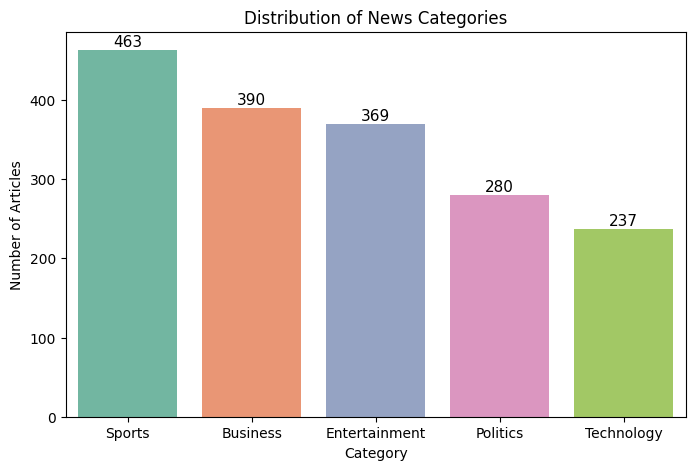

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(data=news_df,x="category",order=news_df["category"].value_counts().index,palette="Set2")
plt.title("Distribution of News Categories")
plt.xlabel("Category")
plt.ylabel("Number of Articles")

for i, value in enumerate(news_df["category"].value_counts().values):
    plt.text(i, value + 5, str(value), ha='center', fontsize=11)

plt.show()

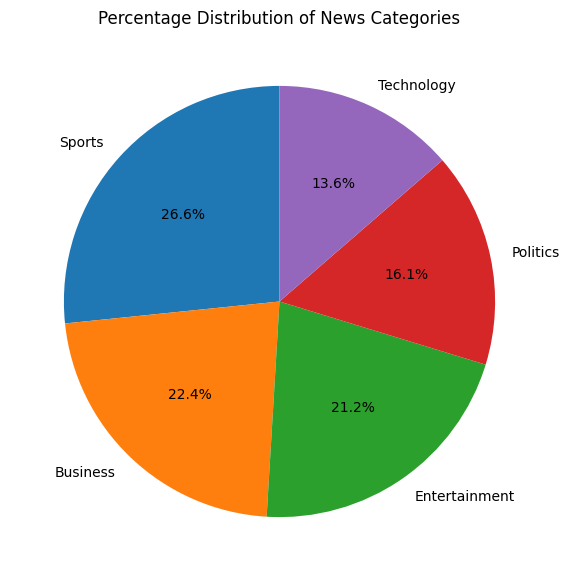

In [33]:
plt.figure(figsize=(7,7))
news_df["category"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.ylabel("")
plt.title("Percentage Distribution of News Categories")
plt.show()

In [34]:
news_df["article_length"] = news_df["description"].apply(len)

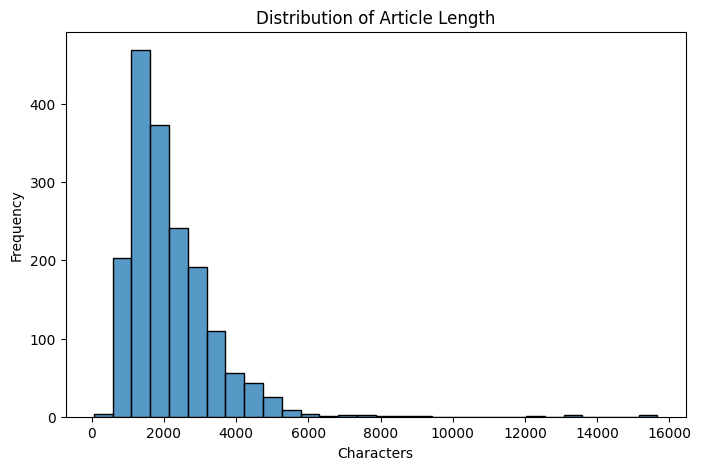

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(news_df["article_length"], bins=30)
plt.title("Distribution of Article Length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

In [36]:
news_df["word_count"] = news_df["description"].apply(lambda x: len(x.split()))

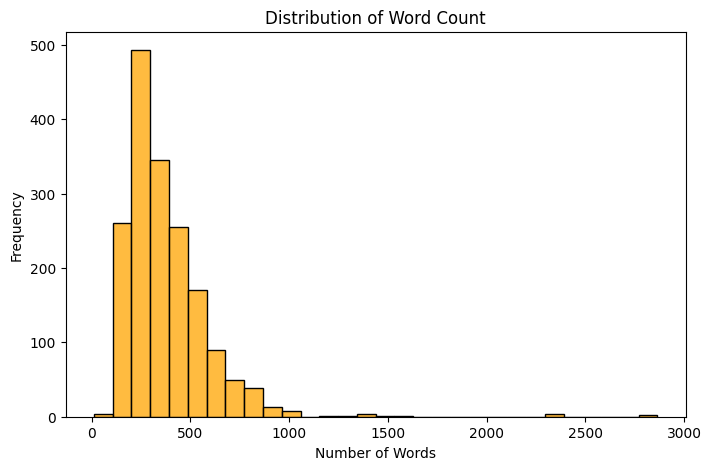

In [37]:
plt.figure(figsize=(8,5))
sns.histplot(news_df["word_count"], bins=30, color="orange")
plt.title("Distribution of Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

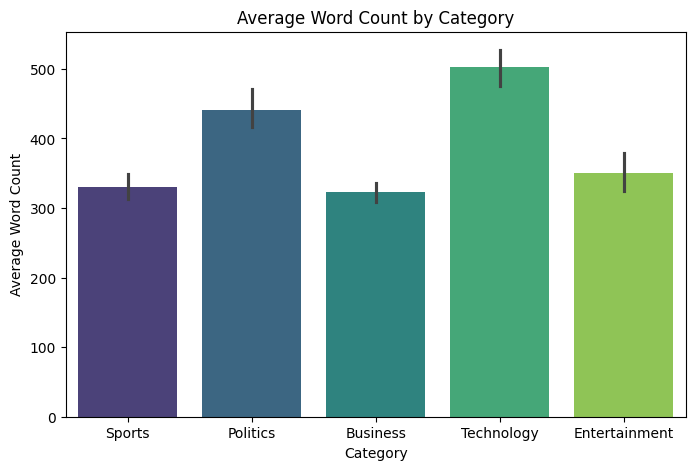

In [38]:
plt.figure(figsize=(8,5))
sns.barplot(data=news_df,x="category",y="word_count",estimator="mean",palette="viridis")
plt.title("Average Word Count by Category")
plt.xlabel("Category")
plt.ylabel("Average Word Count")
plt.show()

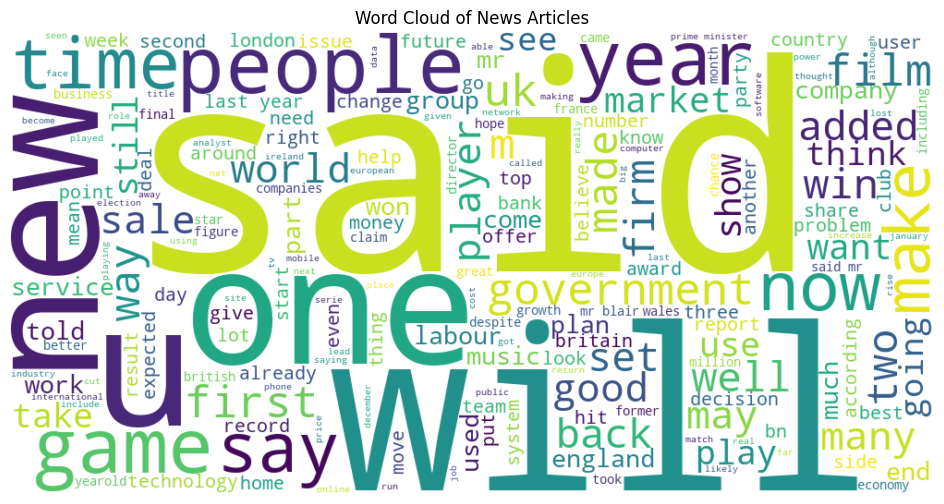

In [39]:
from wordcloud import WordCloud
text = " ".join(news_df["description"])
wordcloud = WordCloud(width=1000,height=500,background_color="white").generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of News Articles")
plt.show()

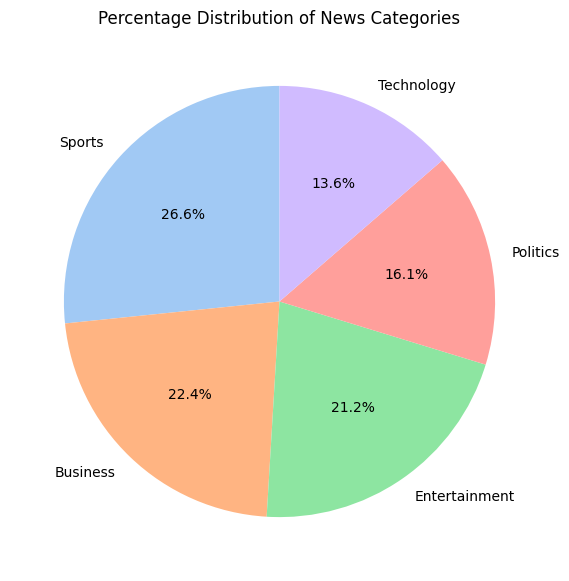

In [40]:
plt.figure(figsize=(7,7))
news_df["category"].value_counts().plot(kind="pie",autopct="%1.1f%%",startangle=90,colors=sns.color_palette("pastel"))
plt.title("Percentage Distribution of News Categories")
plt.ylabel("")
plt.show()

In [41]:
from collections import Counter

text = " ".join(news_df["description"]).lower()
words = text.split()
word_freq = Counter(words)
common_words = word_freq.most_common(20)
freq_df = pd.DataFrame(common_words, columns=["Word","Frequency"])
freq_df

,Word,Frequency
0,the,40894
1,to,19152
2,of,15226
3,and,14364
4,a,14284
5,in,13796
6,for,6931
7,is,6590
8,that,6047
9,on,5859


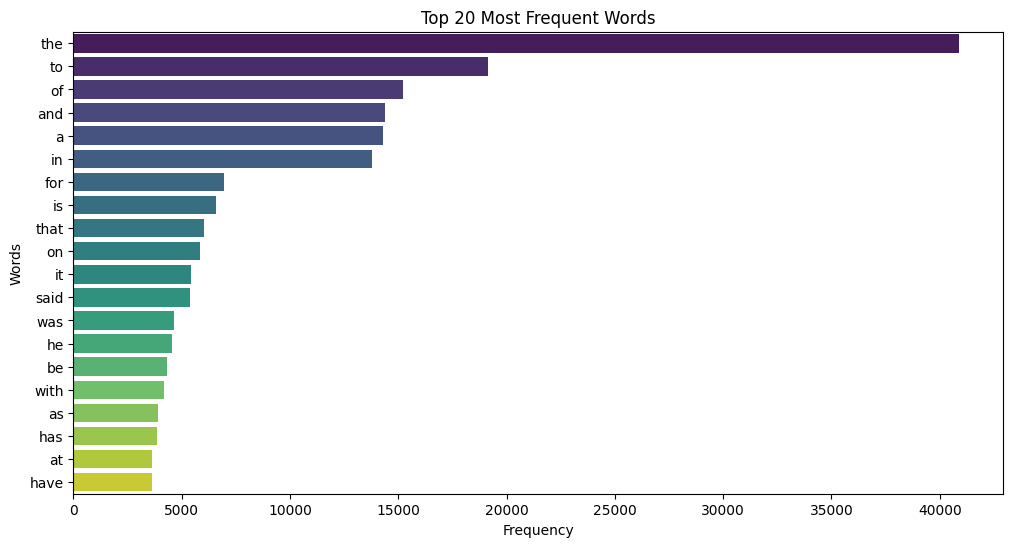

In [42]:
plt.figure(figsize=(12,6))
sns.barplot(data=freq_df,x="Frequency",y="Word",palette="viridis")
plt.title("Top 20 Most Frequent Words")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

In [43]:
from nltk.corpus import stopwords
import nltk

nltk.download("stopwords")
stop_words = set(stopwords.words("english"))
filtered_words = [
    word for word in words
    if word.isalpha() and word not in stop_words
]
word_freq = Counter(filtered_words)
common_words = word_freq.most_common(20)
freq_df = pd.DataFrame(common_words, columns=["Word","Frequency"])

[nltk_data] Downloading package stopwords to C:\Users\Pratham
[nltk_data]     Vernekar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


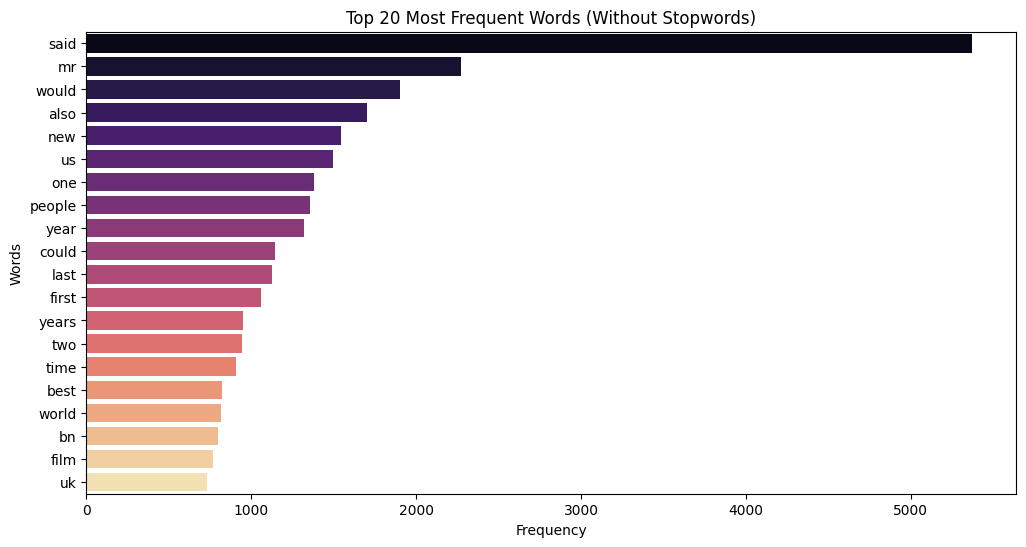

In [44]:
plt.figure(figsize=(12,6))
sns.barplot(data=freq_df,x="Frequency",y="Word",palette="magma")
plt.title("Top 20 Most Frequent Words (Without Stopwords)")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

In [45]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to C:\Users\Pratham
[nltk_data]     Vernekar\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Pratham
[nltk_data]     Vernekar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Pratham
[nltk_data]     Vernekar\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Pratham
[nltk_data]     Vernekar\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [46]:
news_df["clean_text"] = news_df["description"]

In [47]:
news_df["clean_text"] = news_df["clean_text"].str.lower()

In [48]:
news_df["clean_text"] = news_df["clean_text"].apply(
    lambda x: re.sub(r"http\S+|www\S+", "", x)
)

In [49]:
news_df["clean_text"] = news_df["clean_text"].apply(
    lambda x: re.sub(r"<.*?>", "", x)
)

In [50]:
news_df["clean_text"] = news_df["clean_text"].apply(
    lambda x: x.translate(str.maketrans("", "", string.punctuation))
)

In [51]:
news_df["clean_text"] = news_df["clean_text"].apply(
    lambda x: re.sub(r"\d+", "", x)
)

In [52]:
news_df[["description", "clean_text"]].head(10)

,description,clean_text
0,chelsea sack mutu chelsea have sacked adrian ...,chelsea sack mutu chelsea have sacked adrian ...
1,record fails to lift lacklustre meet yelena i...,record fails to lift lacklustre meet yelena i...
2,edu describes tunnel fracas arsenals edu has ...,edu describes tunnel fracas arsenals edu has ...
3,ogara revels in ireland victory ireland flyha...,ogara revels in ireland victory ireland flyha...
4,unclear future for striker baros liverpool fo...,unclear future for striker baros liverpool fo...
5,ronaldo considering new contract manchester u...,ronaldo considering new contract manchester u...
6,dawson wins england squad recall wasps scrumh...,dawson wins england squad recall wasps scrumh...
7,man utd through after exeter test manchester ...,man utd through after exeter test manchester ...
8,barkley fit for match in ireland england cent...,barkley fit for match in ireland england cent...
9,bristol city milton keynes leroy lita took h...,bristol city milton keynes leroy lita took h...


In [53]:
news_df[["description", "clean_text"]].tail(10)

,description,clean_text
1729,verizon seals takeover of mci verizon has won...,verizon seals takeover of mci verizon has won...
1730,europe blames us over weak dollar european le...,europe blames us over weak dollar european le...
1731,building giant in asbestos payout australian ...,building giant in asbestos payout australian ...
1732,why few targets are better than many the econ...,why few targets are better than many the econ...
1733,japan bank shares up on link talk shares of s...,japan bank shares up on link talk shares of s...
1734,nasdaq planning mshare sale the owner of the ...,nasdaq planning mshare sale the owner of the ...
1735,fed chief warning on us deficit federal reser...,fed chief warning on us deficit federal reser...
1736,gm in crunch talks on fiat future fiat will m...,gm in crunch talks on fiat future fiat will m...
1737,winndixie files for bankruptcy us supermarket...,winndixie files for bankruptcy us supermarket...
1738,algeria hit by further gas riots algeria suff...,algeria hit by further gas riots algeria suff...


In [54]:
news_df["tokens"] = news_df["clean_text"].apply(word_tokenize)

In [55]:
news_df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,chelsea sack mutu chelsea have sacked adrian ...,"[chelsea, sack, mutu, chelsea, have, sacked, a..."
1,record fails to lift lacklustre meet yelena i...,"[record, fails, to, lift, lacklustre, meet, ye..."
2,edu describes tunnel fracas arsenals edu has ...,"[edu, describes, tunnel, fracas, arsenals, edu..."
3,ogara revels in ireland victory ireland flyha...,"[ogara, revels, in, ireland, victory, ireland,..."
4,unclear future for striker baros liverpool fo...,"[unclear, future, for, striker, baros, liverpo..."


In [56]:
stop_words = set(stopwords.words("english"))

news_df["tokens"] = news_df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

In [57]:
news_df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,chelsea sack mutu chelsea have sacked adrian ...,"[chelsea, sack, mutu, chelsea, sacked, adrian,..."
1,record fails to lift lacklustre meet yelena i...,"[record, fails, lift, lacklustre, meet, yelena..."
2,edu describes tunnel fracas arsenals edu has ...,"[edu, describes, tunnel, fracas, arsenals, edu..."
3,ogara revels in ireland victory ireland flyha...,"[ogara, revels, ireland, victory, ireland, fly..."
4,unclear future for striker baros liverpool fo...,"[unclear, future, striker, baros, liverpool, f..."


In [58]:
lemmatizer = WordNetLemmatizer()

In [59]:
news_df["tokens"] = news_df["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

In [60]:
news_df["processed_text"] = news_df["tokens"].apply(lambda words: " ".join(words))

In [61]:
news_df[
    [
        "description",
        "clean_text",
        "tokens",
        "processed_text"
    ]
].tail()

,description,clean_text,tokens,processed_text
1734,nasdaq planning mshare sale the owner of the ...,nasdaq planning mshare sale the owner of the ...,"[nasdaq, planning, mshare, sale, owner, techno...",nasdaq planning mshare sale owner technologydo...
1735,fed chief warning on us deficit federal reser...,fed chief warning on us deficit federal reser...,"[fed, chief, warning, u, deficit, federal, res...",fed chief warning u deficit federal reserve ch...
1736,gm in crunch talks on fiat future fiat will m...,gm in crunch talks on fiat future fiat will m...,"[gm, crunch, talk, fiat, future, fiat, meet, c...",gm crunch talk fiat future fiat meet car giant...
1737,winndixie files for bankruptcy us supermarket...,winndixie files for bankruptcy us supermarket...,"[winndixie, file, bankruptcy, u, supermarket, ...",winndixie file bankruptcy u supermarket group ...
1738,algeria hit by further gas riots algeria suff...,algeria hit by further gas riots algeria suff...,"[algeria, hit, gas, riot, algeria, suffered, w...",algeria hit gas riot algeria suffered weekend ...


In [62]:
custom_stopwords = {
    "said",
    "mr",
    "mrs",
    "would",
    "also",
    "one",
    "two"
}

stop_words.update(custom_stopwords)

In [63]:
news_df["tokens"] = news_df["clean_text"].apply(word_tokenize)

news_df["tokens"] = news_df["tokens"].apply(
    lambda words: [word for word in words if word not in stop_words]
)

news_df["tokens"] = news_df["tokens"].apply(
    lambda words: [lemmatizer.lemmatize(word) for word in words]
)

news_df["processed_text"] = news_df["tokens"].apply(lambda words: " ".join(words))

In [64]:
news_df.shape

(1739, 7)

In [66]:
tfidf = TfidfVectorizer(max_features=5000,ngram_range=(1,2))

In [67]:
X = tfidf.fit_transform(news_df["processed_text"])

In [68]:
y = news_df["category"]

In [69]:
print("TF-IDF Matrix Shape :", X.shape)
print("Target Shape :", y.shape)

TF-IDF Matrix Shape : (1739, 5000)
Target Shape : (1739,)


In [70]:
feature_names = tfidf.get_feature_names_out()
print(feature_names[:30])

['aaa' 'abandoned' 'abbas' 'abc' 'ability' 'able' 'abn' 'abortion'
 'abroad' 'absence' 'absolute' 'absolutely' 'abuse' 'ac' 'academy'
 'academy award' 'accept' 'accepted' 'access' 'accessible' 'accident'
 'according' 'according analyst' 'according report' 'account'
 'account deficit' 'accounting' 'accurate' 'accused' 'accusing']


In [71]:
tfidf_df = pd.DataFrame(
    X.toarray()[:5],
    columns=tfidf.get_feature_names_out()
)

tfidf_df.iloc[:, :15]

,aaa,abandoned,abbas,abc,ability,able,abn,abortion,abroad,absence,absolute,absolutely,abuse,ac,academy
0,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.064686,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.000000,0.0,0.0,0.0,0.0,0.040384,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.000000,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [74]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

In [75]:
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)

print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

X_train : (1391, 5000)
X_test  : (348, 5000)
y_train : (1391,)
y_test  : (348,)


In [77]:
nb_model = MultinomialNB()

In [78]:
nb_model.fit(X_train, y_train)

MultinomialNB()

In [79]:
y_pred_nb = nb_model.predict(X_test)

In [81]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy : {accuracy_nb:.4f}")

Naive Bayes Accuracy : 0.9684


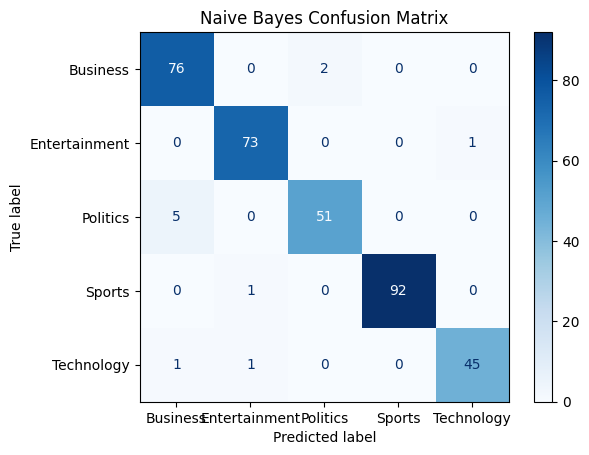

In [83]:
cm = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=nb_model.classes_
)

disp.plot(cmap="Blues")

plt.title("Naive Bayes Confusion Matrix")

plt.show()

In [85]:
print(classification_report(y_test, y_pred_nb))

               precision    recall  f1-score   support

     Business       0.93      0.97      0.95        78
Entertainment       0.97      0.99      0.98        74
     Politics       0.96      0.91      0.94        56
       Sports       1.00      0.99      0.99        93
   Technology       0.98      0.96      0.97        47

     accuracy                           0.97       348
    macro avg       0.97      0.96      0.97       348
 weighted avg       0.97      0.97      0.97       348



In [87]:
lr_model = LogisticRegression(max_iter=1000,random_state=42)

In [88]:
lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [89]:
y_pred_lr = lr_model.predict(X_test)

In [91]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy : {accuracy_lr:.4f}")

Logistic Regression Accuracy : 0.9655


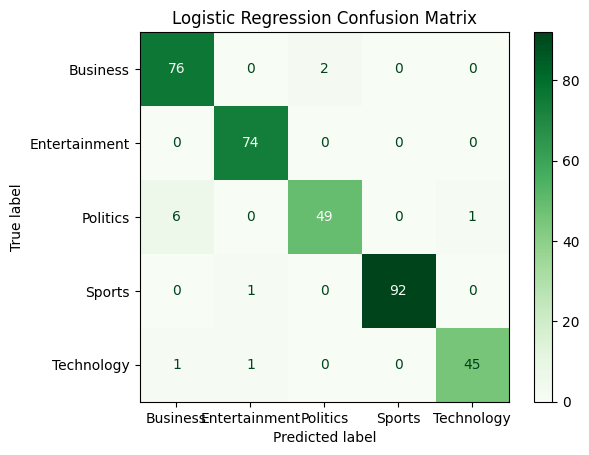

In [92]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=lr_model.classes_
)

disp.plot(cmap="Greens")

plt.title("Logistic Regression Confusion Matrix")

plt.show()

In [93]:
print(classification_report(y_test, y_pred_lr))

               precision    recall  f1-score   support

     Business       0.92      0.97      0.94        78
Entertainment       0.97      1.00      0.99        74
     Politics       0.96      0.88      0.92        56
       Sports       1.00      0.99      0.99        93
   Technology       0.98      0.96      0.97        47

     accuracy                           0.97       348
    macro avg       0.97      0.96      0.96       348
 weighted avg       0.97      0.97      0.97       348



In [95]:
svm_model = LinearSVC(random_state=42)

In [96]:
svm_model.fit(X_train, y_train)

LinearSVC(random_state=42)

In [97]:
y_pred_svm = svm_model.predict(X_test)

In [98]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print(f"Linear SVM Accuracy : {accuracy_svm:.4f}")

Linear SVM Accuracy : 0.9655


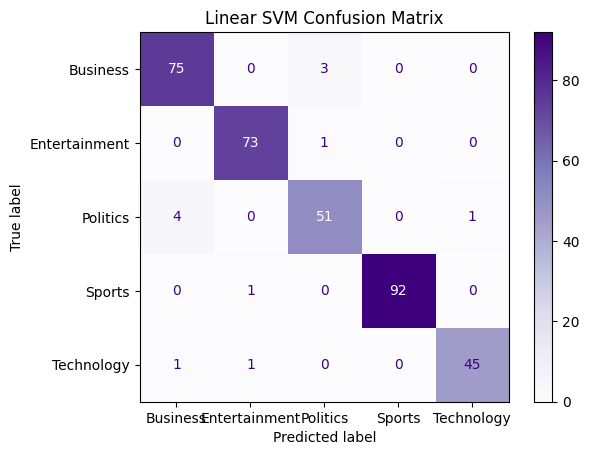

In [99]:
cm_svm = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_model.classes_
)

disp.plot(cmap="Purples")

plt.title("Linear SVM Confusion Matrix")

plt.show()

In [100]:
print(classification_report(y_test, y_pred_svm))

               precision    recall  f1-score   support

     Business       0.94      0.96      0.95        78
Entertainment       0.97      0.99      0.98        74
     Politics       0.93      0.91      0.92        56
       Sports       1.00      0.99      0.99        93
   Technology       0.98      0.96      0.97        47

     accuracy                           0.97       348
    macro avg       0.96      0.96      0.96       348
 weighted avg       0.97      0.97      0.97       348



In [101]:
comparison_df = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        accuracy_nb,
        accuracy_lr,
        accuracy_svm
    ]
})

comparison_df = comparison_df.sort_values(
    by="Accuracy",
    ascending=False
)

comparison_df

,Model,Accuracy
0,Multinomial Naive Bayes,0.968391
1,Logistic Regression,0.965517
2,Linear SVM,0.965517


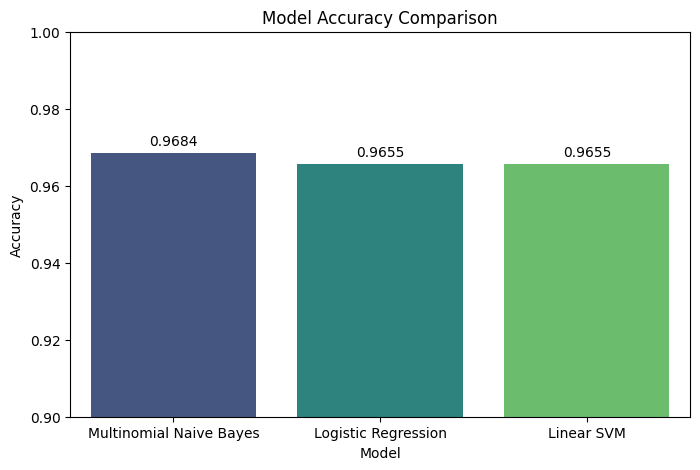

In [102]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="Accuracy",
    palette="viridis"
)

plt.title("Model Accuracy Comparison")
plt.ylim(0.90,1.00)

for i, value in enumerate(comparison_df["Accuracy"]):
    plt.text(i, value+0.002, f"{value:.4f}", ha="center")

plt.show()

In [103]:
def predict_news(text):
    
    # Lowercase
    text = text.lower()
    
    # Remove punctuation
    text = re.sub(r"[^\w\s]", "", text)
    
    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Tokenize
    words = word_tokenize(text)

    # Remove stopwords
    words = [w for w in words if w not in stop_words]

    # Lemmatize
    words = [lemmatizer.lemmatize(w) for w in words]

    # Join words
    text = " ".join(words)

    # TF-IDF transform
    vector = tfidf.transform([text])

    # Predict
    prediction = nb_model.predict(vector)

    return prediction[0]

In [104]:
news = "India defeated Australia in the cricket world cup final."

print("Predicted Category :", predict_news(news))

Predicted Category : Sports


In [105]:
news = "Apple launched its latest AI powered smartphone."

print("Predicted Category :", predict_news(news))

Predicted Category : Technology


In [106]:
news = "The stock market witnessed a huge rise in company shares."

print("Predicted Category :", predict_news(news))

Predicted Category : Business


In [108]:
joblib.dump(nb_model, "news_classifier.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [115]:
news = "mobile"
print("Predicted Category :", predict_news(news))

Predicted Category : Technology


In [1]:
%pwd

'C:\\Users\\Pratham Vernekar\\ATA_NLP_Mini_Project_1'